## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [3]:
# Creating Dataset connection
conn = sqlite3.connect('inventory.db')

#Fetching vendor summary data 
df = pd.read_sql_query(" select * from Vendor_Sales_Summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasesQuantity,TotalPurchasesDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchasesRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


## Exploratory Data Analysis (EDA)
* In the previous step, we explored the different tables in the database to understand the data, identify important columns, and select the features required for our analysis.
* In this EDA phase, we will analyze the final dataset to understand the distribution of each column, identify missing values and outliers, discover patterns and trends, and ensure the data is clean and ready for further analysis and visualization

In [4]:
# Summary Statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchasesQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchasesDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


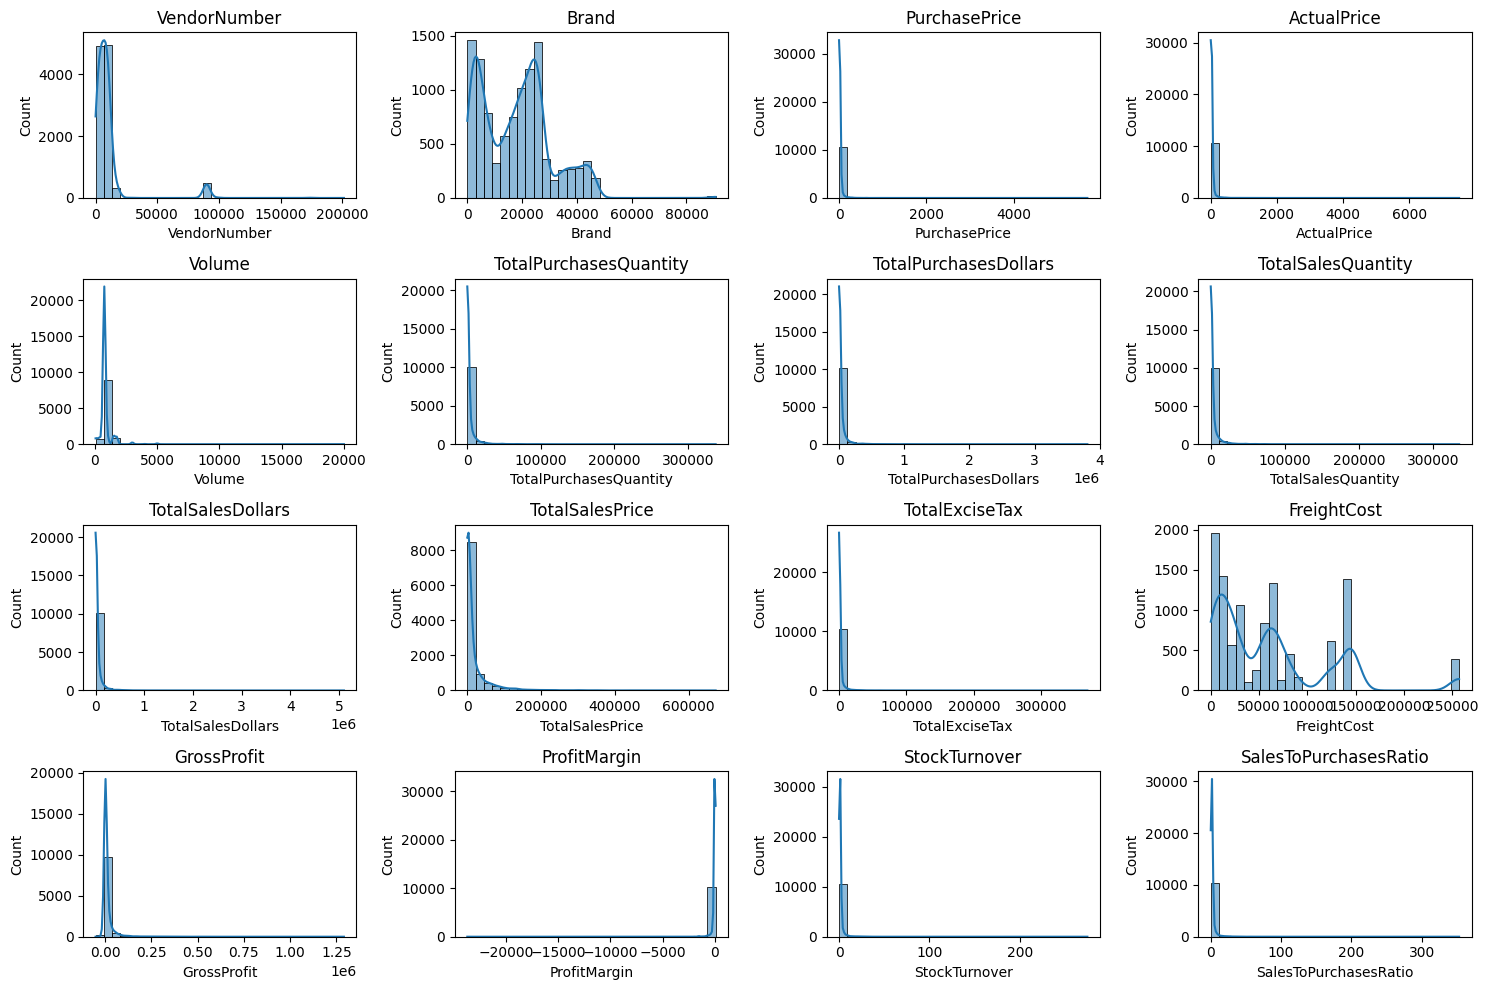

In [5]:
# Distribution Plot for Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # Adjust grid layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()
    

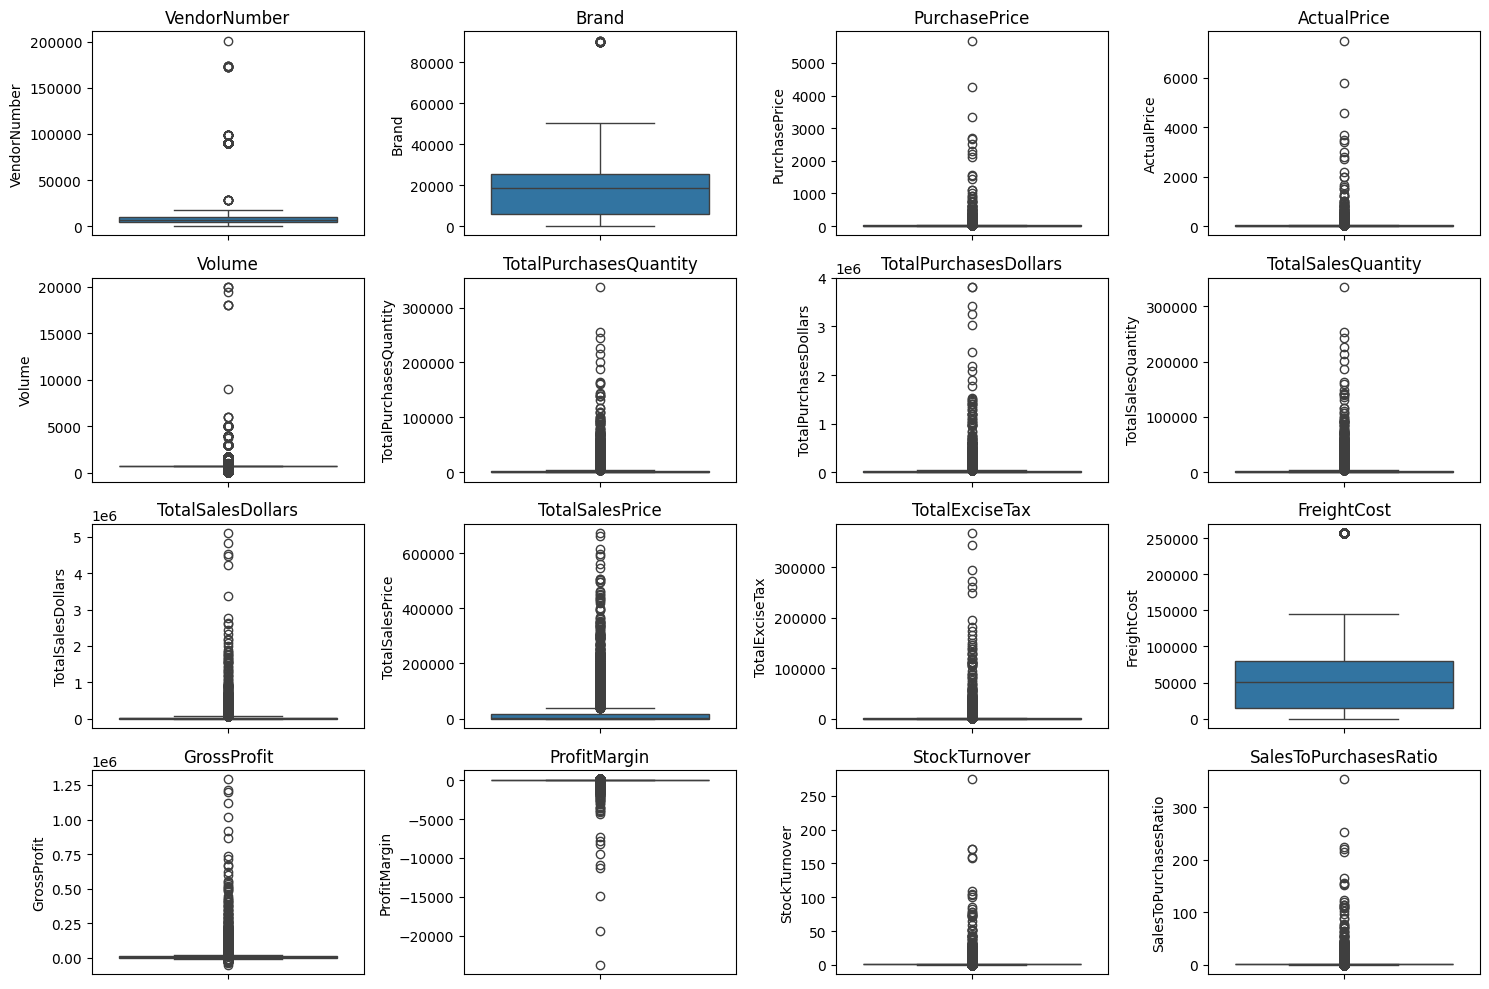

In [6]:
# Outlier Detection with Boxplots

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics Insights
### Negative & Zero Values
* Gross Profit : The minimum Gross Profit is -52,002.78, which indicates that some products were sold at a loss. This may happen because the purchase cost was higher than the selling price or due to heavy discounts.
* Profit Margin: The minimum value is -∞ (negative infinity). This occurred because some products had zero sales, making the profit margin calculation invalid.
* Total Sales Quantity & Total Sales Dollars: The minimum value is 0, which means some products were purchased but not sold. These products may represent slow-moving or unsold inventory.
### High Values and Outliers
* Purchase Price & Actual Price: The maximum values (5,681.81 and 7,499.99) are much higher than their average values, indicating the presence of premium or high-value products.
* Freight Cost: Freight costs range from 0.09 to 257,032.07, showing a large variation among vendors. This may be due to bulk orders, different shipping methods, or transportation distances.
* Stock Turnover: Stock Turnover ranges from 0 to 274.5. A value greater than 1 suggests that more units were sold than purchased during the analysis period, possibly because sales were fulfilled using existing inventory from previous stock.
### Overall Business Insight
* Some products are generating losses, while others are highly profitable.
* Premium products create higher purchase and selling prices.
* Some products have zero sales, which should be reviewed further.
* Freight costs vary significantly across vendors.
* The dataset contains business outliers, which represent genuine business scenarios rather than data errors.

In [7]:
# Let's Filter The Data by Removing Inconsistancies
df= pd.read_sql_query(""" select *
from Vendor_Sales_Summary
where GrossProfit>0
and ProfitMargin>0
and TotalSalesQuantity>0""",conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchasesQuantity,TotalPurchasesDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchasesRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


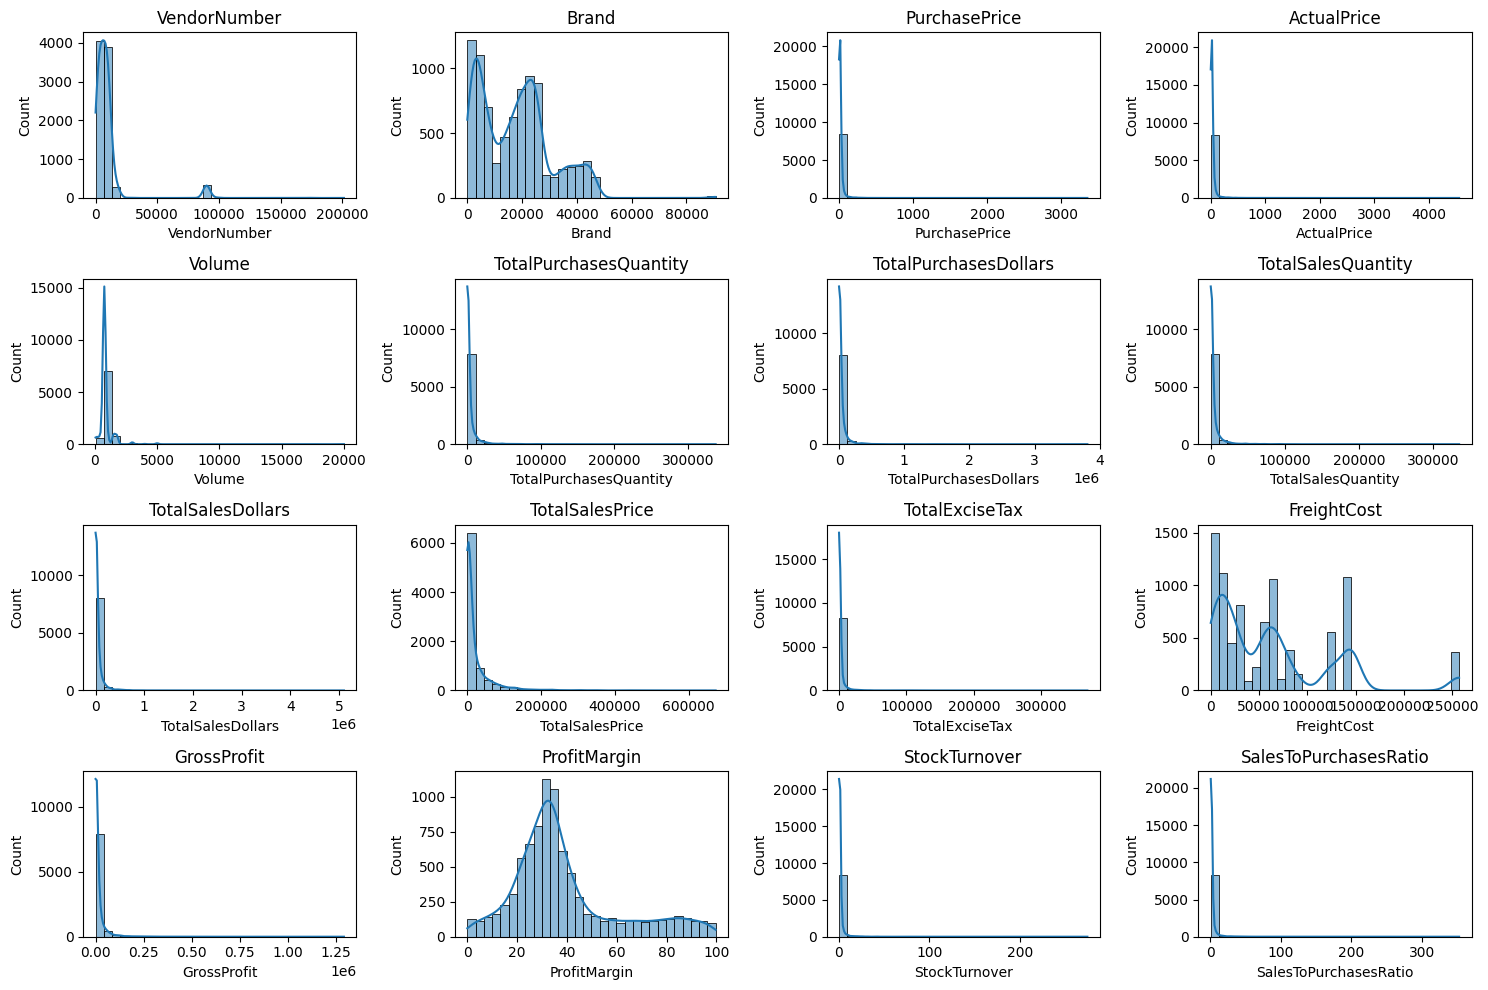

In [9]:
# Distribution Plot for Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) # Adjust grid layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()
    

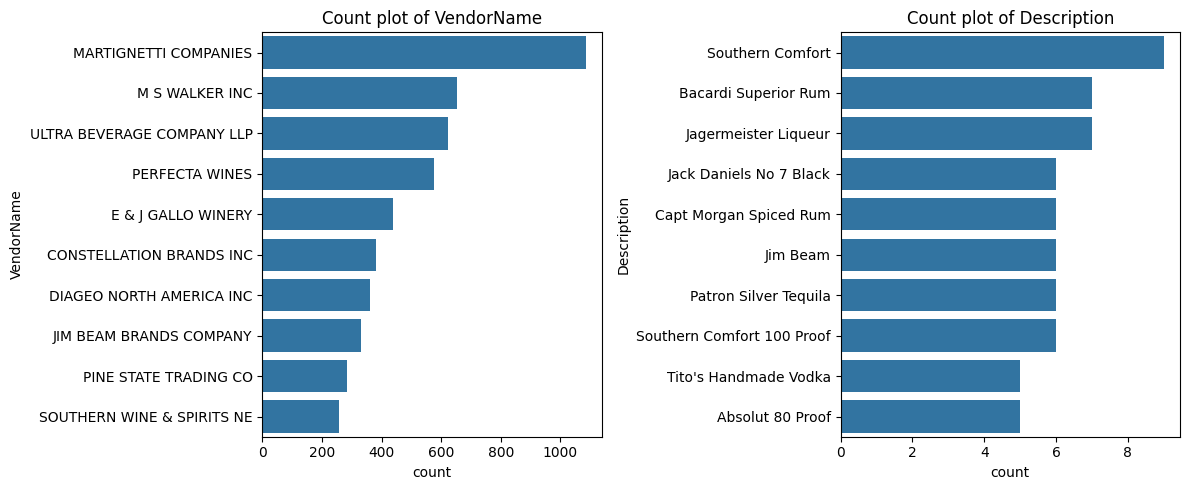

In [10]:
# Count Plots For Categorical Columns

categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()

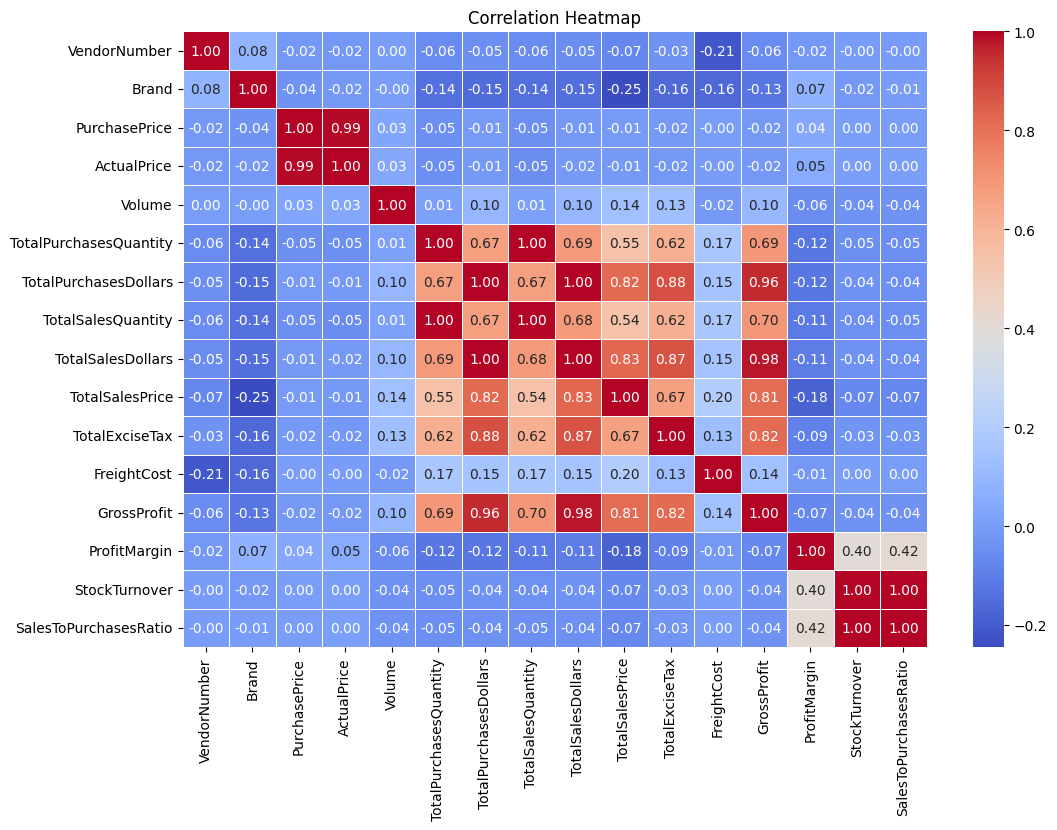

In [11]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f" , cmap="coolwarm" , linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights

The correlation heatmap helps us understand how different business variables are related to each other. A value close to **1** indicates a strong positive relationship, while a value close to **-1** indicates a strong negative relationship. A value close to **0** means there is little or no relationship.

### Key Insights

- **Purchase Price and Actual Price** have a **very strong positive correlation (0.99)**. This shows that products with higher purchase prices are usually sold at higher selling prices.

- **Purchase Price** has a **very weak negative correlation** with **Total Sales Dollars** and **Gross Profit**. This means that increasing the purchase price alone does not significantly improve sales revenue or profit.

- **Total Purchases Quantity** and **Total Sales Quantity** have a **very strong positive correlation (≈1.00)**. This indicates that products purchased in higher quantities are generally sold in higher quantities, showing efficient inventory movement.

- **Total Sales Dollars** and **Gross Profit** have a **very strong positive correlation (0.98)**. Higher sales revenue directly contributes to higher business profit.

- **Total Purchases Dollars** and **Gross Profit** also have a **strong positive correlation (0.96)**. This suggests that products with higher purchase investment generally generate higher profits.

- **Total Sales Price** has a **strong positive relationship** with **Gross Profit (0.81)**, showing that products sold at higher prices usually contribute more to profit.

- **Profit Margin** has a **weak negative correlation (-0.18)** with **Total Sales Price**. This indicates that selling a product at a higher price does not always result in a higher profit margin.

- **Stock Turnover** has a **weak negative correlation** with **Gross Profit** and **Profit Margin**. This means that products with faster inventory movement do not always generate higher profitability.

- **Freight Cost** shows only a **weak relationship** with sales and profit, indicating that transportation cost has a limited impact on overall business performance.

- **Vendor Number** and **Brand** have very low correlations with other variables because they are identifier columns and do not directly affect business performance.

---

## Overall Business Insight

The correlation analysis shows that **sales, purchases, and profit are strongly connected**. Products with higher sales generally generate higher profits, while premium products are usually sold at higher prices. At the same time, purchase price, freight cost, and stock turnover alone do not guarantee better profitability. These insights help identify the key factors that influence vendor performance and business growth.

# DATA ANALYSIS (SOLVE RESHEARCH QUESTIONS)

####  Idenifiy Brands that needs Promotional or Pricing Adjustments Which exhibit lower sales Performance But higher Profit Margins.

In [12]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [13]:
low_sales_thresold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_thresold = brand_performance['ProfitMargin'].quantile(0.85)

In [14]:
low_sales_thresold

np.float64(560.299)

In [15]:
high_margin_thresold

np.float64(64.97017552750113)

In [16]:
# Filter Brands With Low Sales But High Profit Margins
target_brand = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_thresold) &
     (brand_performance['ProfitMargin'] >= high_margin_thresold )]
print("Brands with Low Sales but High Profit Margin")
display(target_brand.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margin


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


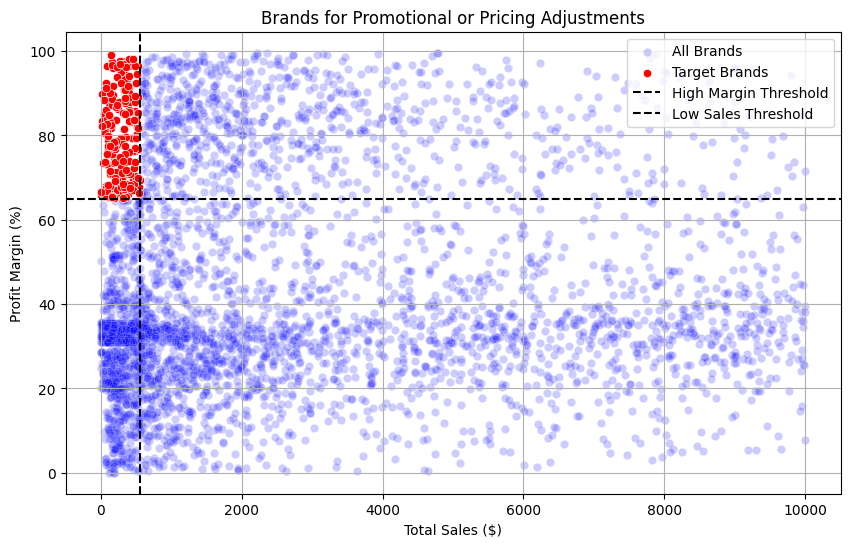

In [17]:
# Filtering brands with Total Sales less than $10,000 for better visualization
brand_performance = brand_performance[
    brand_performance['TotalSalesDollars'] < 10000
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

sns.scatterplot(
    data=target_brand,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
   high_margin_thresold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    low_sales_thresold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)

plt.show()

#### 2. Which Vendors And Brands Demonstrate the Highest Sales Performance

In [18]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)


In [19]:
# Top Vendors & Brands by Sales Performance
top_vendors = (
    df.groupby("VendorName")["TotalSalesDollars"]
      .sum()
      .nlargest(10)
)

top_brands = (
    df.groupby("Description")["TotalSalesDollars"]
      .sum()
      .nlargest(10)
)

top_vendors.apply(lambda x : format_dollars(x))


VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: str

In [20]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

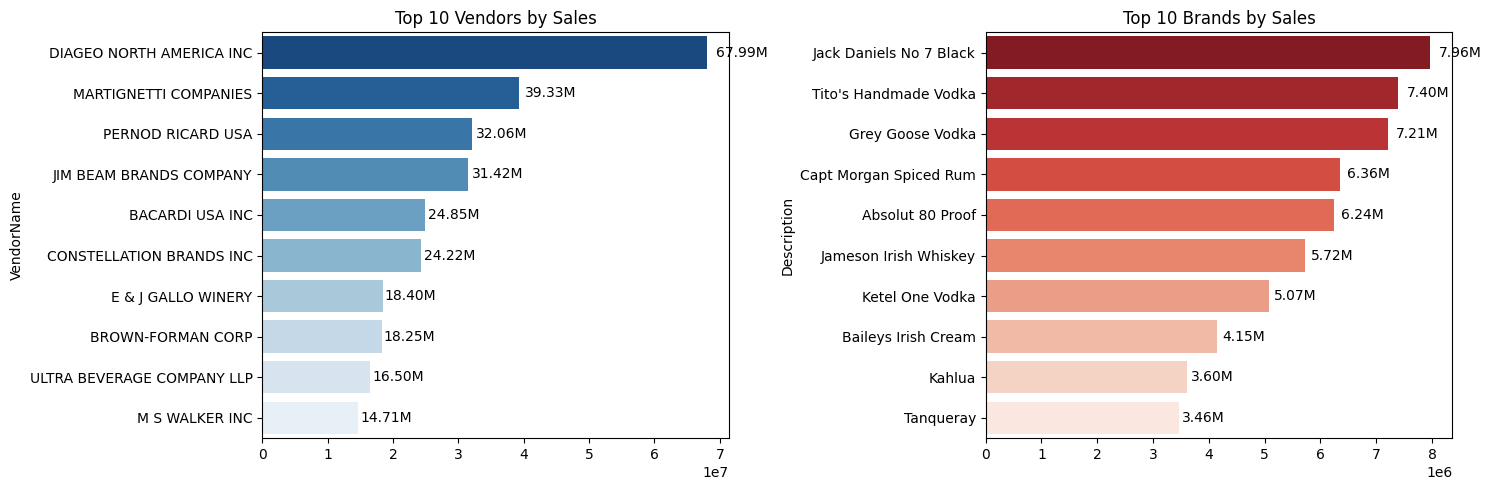

In [21]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

#### 3. Which Vendors contribute the most to total purchase dollars

In [22]:
vendor_performance = df.groupby('VendorName').agg({
    "TotalPurchasesDollars" :"sum",
    "GrossProfit": "sum",
    "TotalSalesDollars":"sum"
}).reset_index()

In [23]:
vendor_performance['PuchaseContribution%'] = vendor_performance['TotalPurchasesDollars']/ vendor_performance['TotalPurchasesDollars'].sum() * 100

In [24]:
vendor_performance = round(vendor_performance.sort_values('PuchaseContribution%' ,ascending = False),2)

In [25]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = (
    top_vendors['TotalSalesDollars'].apply(format_dollars)
)

top_vendors['TotalPurchasesDollars'] = (
    top_vendors['TotalPurchasesDollars'].apply(format_dollars)
)

top_vendors['GrossProfit'] = (
    top_vendors['GrossProfit'].apply(format_dollars)
)

top_vendors

,VendorName,TotalPurchasesDollars,GrossProfit,TotalSalesDollars,PuchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [26]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PuchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchasesDollars,GrossProfit,TotalSalesDollars,PuchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


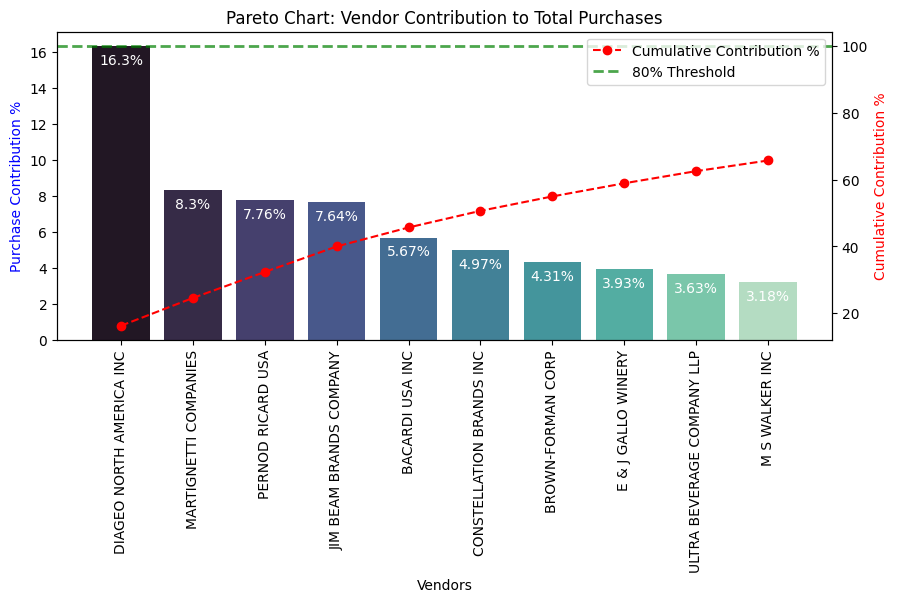

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# Bar plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PuchaseContribution%'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['PuchaseContribution%']):
    ax1.text(
        i,
        value - 1,
        str(value) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='green', linestyle='dashed', alpha=0.7,linewidth = 2 , label = '80% Threshold')
ax2.legend(loc='upper right')

plt.show()

#### 4. How much of total procurement is dependent on the top vendors?

In [28]:
print(f"Total Purchase Contribution Of Top 10 vendors is {round(top_vendors['PuchaseContribution%'].sum(),2)}%")

Total Purchase Contribution Of Top 10 vendors is 65.69%


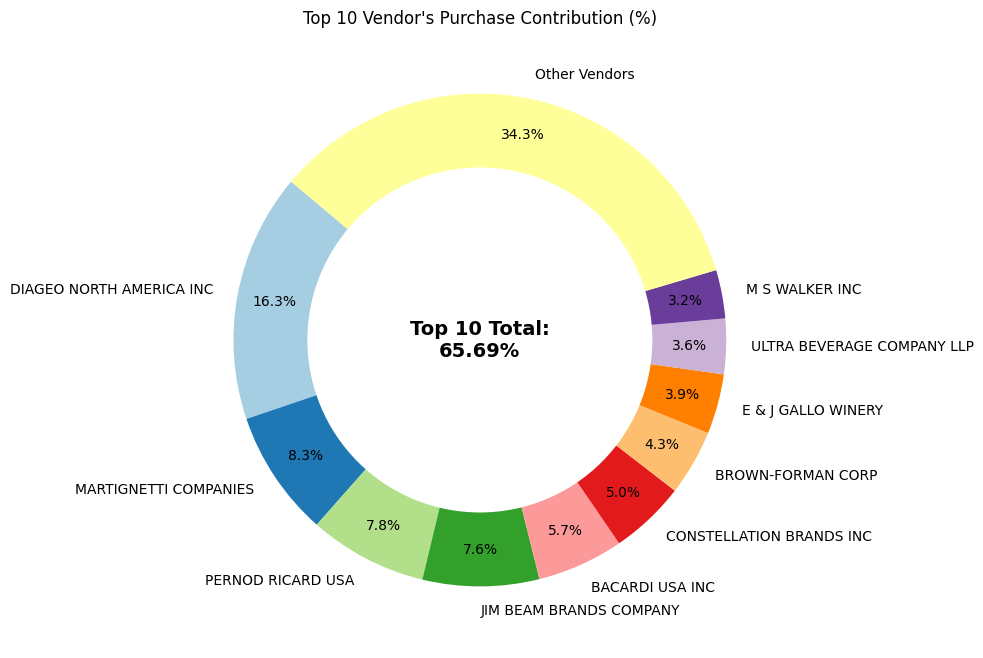

In [29]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PuchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

## Procurement Dependency Insights

### Insights

- The Top 10 vendors contribute **65.69%** of the company's total procurement, showing that most purchases come from a small group of suppliers.
- **DIAGEO NORTH AMERICA INC** is the largest contributor, accounting for **16.3%** of total purchases.
- The Top 4 vendors together contribute around **40%** of total procurement, indicating a high concentration of purchasing.
- All remaining vendors contribute only **34.3%**, which shows that many vendors have a relatively small impact on overall procurement.
- The company is highly dependent on a few key vendors. While this helps maintain strong supplier relationships, it also increases procurement risk if any major supplier faces delivery issues or changes pricing.

#### 5. Dose Purchasing in bulk reduce the unit price , and what is the optimal purchase volume for cost saving?

In [30]:
# Calculate Unit Purchase Price
df['UnitPurchasePrice'] = (
    df['TotalPurchasesDollars'] / df['TotalPurchasesQuantity']
)

In [31]:
df.UnitPurchasePrice

0       26.27
1       23.19
2       18.24
3       16.17
4       21.89
        ...  
8559     1.32
8560     0.39
8561     0.74
8562     1.47
8563     0.71
Name: UnitPurchasePrice, Length: 8564, dtype: float64

In [32]:
# Create Order Size Categories
df["OrderSize"] = pd.qcut(
    df["TotalPurchasesQuantity"],
    q=3,
    labels=["Small", "Medium", "Large"]
)


In [33]:
# Average Unit Purchase Price by Order Size
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


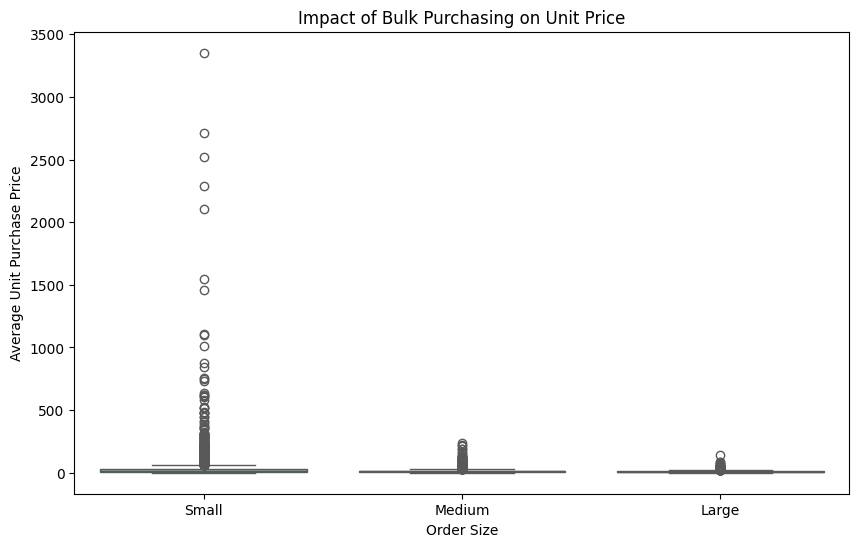

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")

plt.show()

## Insights

- Large purchase orders have the lowest average unit purchase price ($10.78 per unit) while small purchase orders have the highest average unit purchase price ($39.07 per unit).

- The average unit purchase price decreases as the purchase quantity increases, indicating that bulk purchasing helps reduce procurement costs.

- The difference between Small and Large orders is approximately 72%, showing that purchasing in larger quantities provides significant cost savings.

- These findings suggest that the company can improve profitability by purchasing high-demand products in bulk, while maintaining efficient inventory management to avoid overstocking.

#### 6. Which Vendor have low inventory turnover , indicating excess stock and slow-moving products?

In [35]:
vendor_turnover = (
    df.groupby("VendorName")
      .agg({
          "TotalPurchasesQuantity":"sum",
          "TotalSalesQuantity":"sum"
      })
)

vendor_turnover["StockTurnover"] = (
    vendor_turnover["TotalSalesQuantity"] /
    vendor_turnover["TotalPurchasesQuantity"]
)

vendor_turnover.sort_values("StockTurnover").head(10)

,TotalPurchasesQuantity,TotalSalesQuantity,StockTurnover
VendorName,,,
Dunn Wine Brokers,4741,3725.0,0.785699
TAMWORTH DISTILLING,1232,982.0,0.797078
WALPOLE MTN VIEW WINERY,805,662.0,0.822360
SWEETWATER FARM,959,799.0,0.833160
THE IMPORTED GRAPE LLC,1764,1485.0,0.841837
PARK STREET IMPORTS LLC,3006,2574.0,0.856287
BRONCO WINE COMPANY,337,290.0,0.860534
CENTEUR IMPORTS LLC,539,465.0,0.862709
AMERICAN SPIRITS EXCHANGE,96,84.0,0.875000


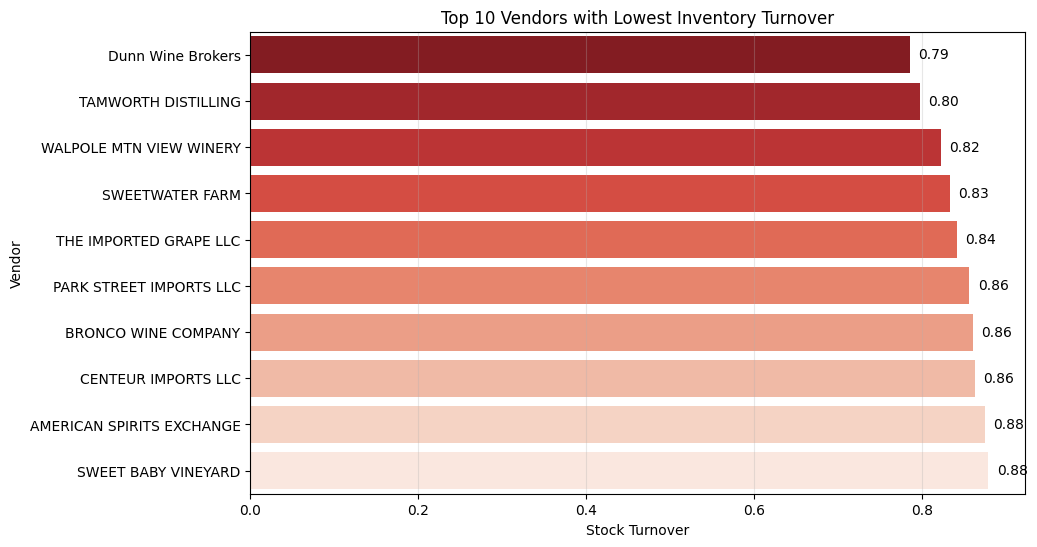

In [36]:
lowest_turnover = (
    vendor_turnover
    .sort_values("StockTurnover")
    .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=lowest_turnover,
    y="VendorName",
    x="StockTurnover",
    palette="Reds_r"
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Vendors with Lowest Inventory Turnover")
plt.xlabel("Stock Turnover")
plt.ylabel("Vendor")

plt.grid(axis="x", alpha=0.3)

plt.show()

##  Insights

- Vendors with the lowest inventory turnover are selling products more slowly than other vendors.

- A low inventory turnover ratio indicates that products remain in inventory for a longer period, increasing inventory holding costs.

- Slow-moving inventory also blocks working capital and reduces warehouse efficiency.

- These vendors should be reviewed to identify products with low customer demand or excess purchasing.

- Improving inventory turnover can help reduce storage costs and improve overall inventory efficiency.

#### 7. How Much capital is locked in unsold inventory per vendor , and which vendors contribution the most to it?

In [37]:
df["UnsoldInventoryValue"] = (df["TotalPurchasesQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print("Total Unsold Capital:",format_dollars(df["UnsoldInventoryValue"].sum()))                                                          

Total Unsold Capital: 2.71M


In [38]:
vendor_locked = (
    df.groupby("VendorName")
      .agg({
          "UnsoldInventoryValue": "sum"
      })
      .sort_values("UnsoldInventoryValue", ascending=False)
      .reset_index()
)

vendor_locked.head(10)

,VendorName,UnsoldInventoryValue
0,DIAGEO NORTH AMERICA INC,722209.05
1,JIM BEAM BRANDS COMPANY,554665.63
2,PERNOD RICARD USA,470625.61
3,WILLIAM GRANT & SONS INC,401960.83
4,E & J GALLO WINERY,228282.61
5,SAZERAC CO INC,198436.41
6,BROWN-FORMAN CORP,177733.74
7,CONSTELLATION BRANDS INC,133617.62
8,MOET HENNESSY USA INC,126477.70
9,REMY COINTREAU USA INC,118598.15


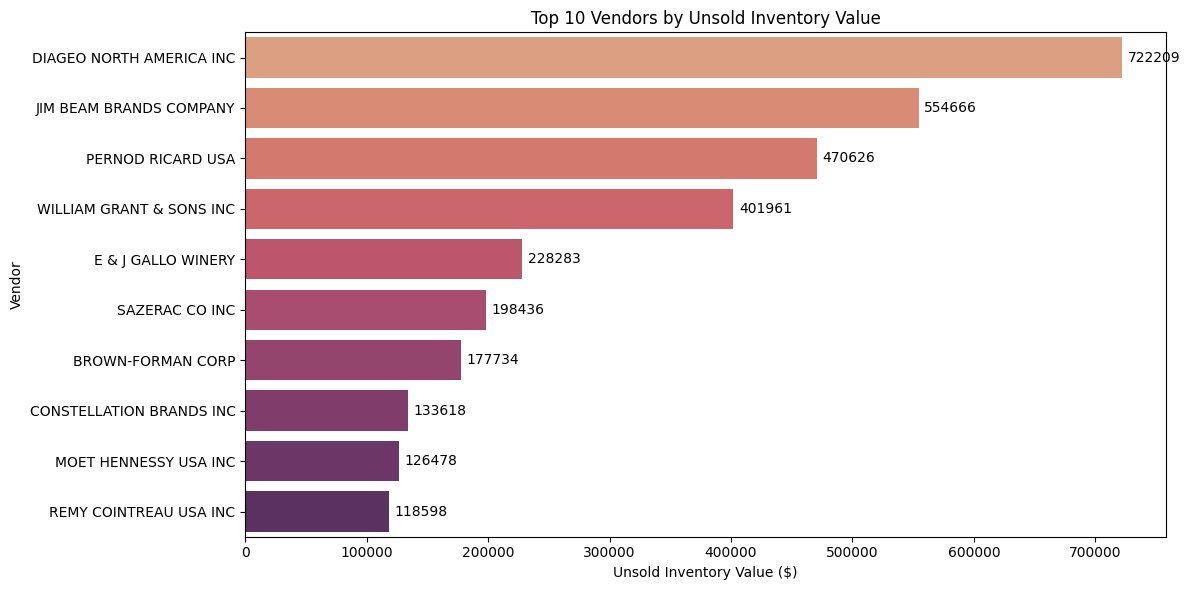

In [39]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=vendor_locked.head(10),
    y="VendorName",
    x="UnsoldInventoryValue",
    palette="flare"
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4
    )

plt.title("Top 10 Vendors by Unsold Inventory Value")
plt.xlabel("Unsold Inventory Value ($)")
plt.ylabel("Vendor")

plt.tight_layout()
plt.show()

## Insights

- The company has approximately **$2.71 million** of capital locked in unsold inventory.
- **DIAGEO NORTH AMERICA INC** has the highest unsold inventory value, followed by **JIM BEAM BRANDS COMPANY** and **PERNOD RICARD USA**.
- Vendors with higher unsold inventory values should be reviewed to reduce excess inventory and improve cash flow.

#### 8. What is the 95% confidence intervels for profit margins of top-performance and low-performance vendors.

In [40]:
# 75th and 25th percentile thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Profit Margins of Top and Low Performing Vendors
top_vendors = (
    df[df["TotalSalesDollars"] >= top_threshold]
    ["ProfitMargin"]
    .dropna()
)

low_vendors = (
    df[df["TotalSalesDollars"] <= low_threshold]
    ["ProfitMargin"]
    .dropna()
)

In [41]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [42]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    
    # Standard Error
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    
    # Critical t-value
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    
    # Margin of Error
    margin_of_error = t_critical * std_err
    
    return (
        mean_val,
        mean_val - margin_of_error,
        mean_val + margin_of_error
    )

In [43]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors Profit Margin (95% CI): ({top_lower:.2f}, {top_upper:.2f})")
print(f"Low Vendors Profit Margin (95% CI): ({low_lower:.2f}, {low_upper:.2f})")

Top Vendors Profit Margin (95% CI): (30.74, 31.61)
Low Vendors Profit Margin (95% CI): (40.50, 42.64)


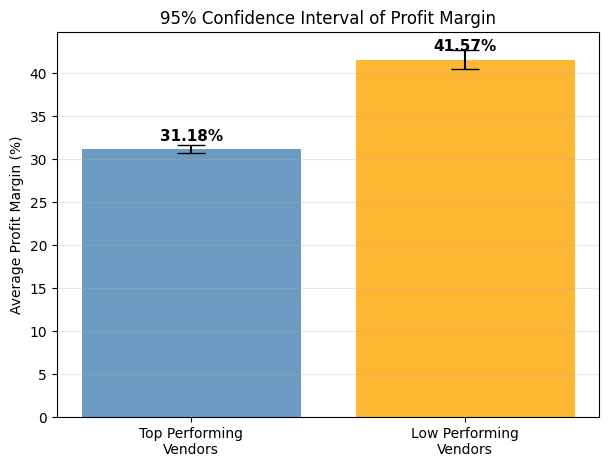

In [44]:
plt.figure(figsize=(7,5))

groups = ["Top Performing\nVendors", "Low Performing\nVendors"]
means = [top_mean, low_mean]

lower_error = [
    top_mean - top_lower,
    low_mean - low_lower
]

upper_error = [
    top_upper - top_mean,
    low_upper - low_mean
]

plt.bar(
    groups,
    means,
    yerr=[lower_error, upper_error],
    capsize=10,
    color=["steelblue", "orange"],
    alpha=0.8
)

plt.ylabel("Average Profit Margin (%)")
plt.title("95% Confidence Interval of Profit Margin")

for i, value in enumerate(means):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.3)

plt.show()

## Insights

- The average profit margin of top-performing vendors lies between **30.74% and 31.61%** with 95% confidence.

- The average profit margin of low-performing vendors lies between **40.50% and 42.64%** with 95% confidence.

- Low-performing vendors have higher profit margins but lower sales volume, while top-performing vendors achieve higher sales with relatively lower margins.

- This suggests that increasing sales volume may require competitive pricing, which can reduce average profit margins.

#### 9. Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:


H₀ (Null Hypothesis):
There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis):
The mean profit margins of top-performing and low-performing vendors are significantly different.


In [45]:

# Calculate 75th and 25th percentile thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Select Profit Margins of Top and Low Performing Vendors
top_vendors = (
    df.loc[df["TotalSalesDollars"] >= top_threshold, "ProfitMargin"]
      .dropna()
)

low_vendors = (
    df.loc[df["TotalSalesDollars"] <= low_threshold, "ProfitMargin"]
      .dropna()
)

# Perform Welch's Two-Sample T-Test
t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)

# Print Results
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Decision
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top-performing and low-performing vendors.")
else:
    print("Fail to Reject H₀: There is no significant difference in profit margins between top-performing and low-performing vendors.")

T-Statistic: -17.6695
P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top-performing and low-performing vendors.


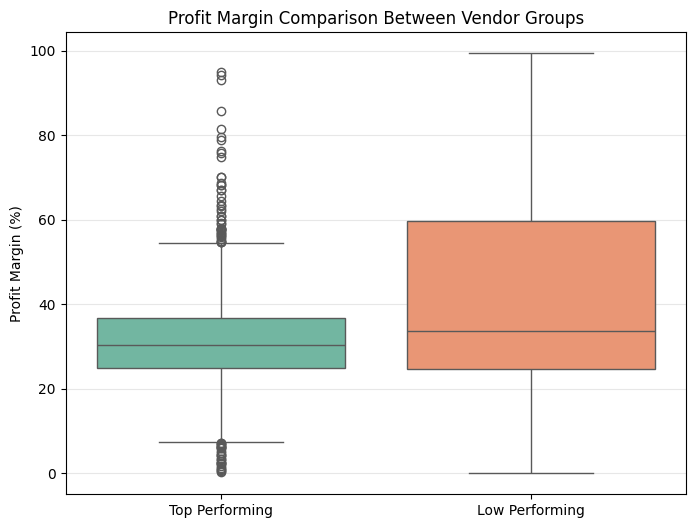

In [46]:
comparison_df = pd.DataFrame({
    "ProfitMargin": pd.concat([top_vendors, low_vendors]),
    "VendorGroup": (
        ["Top Performing"] * len(top_vendors)
        + ["Low Performing"] * len(low_vendors)
    )
})

plt.figure(figsize=(8,6))

sns.boxplot(
    data=comparison_df,
    x="VendorGroup",
    y="ProfitMargin",
    palette="Set2"
)

plt.title("Profit Margin Comparison Between Vendor Groups")
plt.xlabel("")
plt.ylabel("Profit Margin (%)")
plt.grid(axis="y", alpha=0.3)

plt.show()

## Insights

- The statistical test shows a significant difference in profit margins between top-performing and low-performing vendors.

- The p-value (**0.0000**) is much smaller than the significance level (**0.05**), indicating that the observed difference is statistically significant.

- Top-performing vendors generate higher sales but have lower average profit margins.

- Low-performing vendors have higher profit margins but lower sales volume, suggesting that high margins alone do not guarantee strong sales performance.

In [49]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchasesQuantity',
       'TotalPurchasesDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesToPurchasesRatio',
       'UnitPurchasePrice', 'OrderSize', 'UnsoldInventoryValue'],
      dtype='str')

In [48]:
df["ProfitMargin"].head()

0    25.297693
1    21.062810
2    24.675786
3    27.139908
4    28.412764
Name: ProfitMargin, dtype: float64

In [51]:
top_vendors = (
    df.groupby("VendorName", as_index=False)["TotalSalesDollars"]
      .sum()
      .sort_values("TotalSalesDollars", ascending=False)
      .head(10)
)

top_vendors

,VendorName,TotalSalesDollars
25,DIAGEO NORTH AMERICA INC,67990099.42
57,MARTIGNETTI COMPANIES,39330359.36
68,PERNOD RICARD USA,32063196.19
46,JIM BEAM BRANDS COMPANY,31423020.46
6,BACARDI USA INC,24854817.14
20,CONSTELLATION BRANDS INC,24218745.65
30,E & J GALLO WINERY,18399899.46
11,BROWN-FORMAN CORP,18247230.65
106,ULTRA BEVERAGE COMPANY LLP,16502544.31
53,M S WALKER INC,14706458.51


In [52]:
vendor_turnover.sort_values(
    "StockTurnover",
    ascending=False
).head(5)

,TotalPurchasesQuantity,TotalSalesQuantity,StockTurnover
VendorName,,,
FLAVOR ESSENCE INC,1,59.0,59.000000
CAPSTONE INTERNATIONAL,4,13.0,3.250000
SILVER MOUNTAIN CIDERS,17,49.0,2.882353
ALISA CARR BEVERAGES,320,906.0,2.831250
STAR INDUSTRIES INC.,151,424.0,2.807947
